📁 Please upload your UCI_Credit_Card.csv file:


Saving UCI_Credit_Card.csv to UCI_Credit_Card (5).csv

Class distribution before cleaning:
 default
0    23364
1     6636
Name: count, dtype: int64

⚠️ Outlier removal dropped minority class — reverting to unfiltered dataset.

✅ Cleaning complete. Shape: (29965, 24)
Class balance after cleaning:
 default
0    23335
1     6630
Name: count, dtype: int64

Before Resampling:
 default
0    16334
1     4641
Name: count, dtype: int64

After SMOTE:
 default
1    16334
0    16334
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


✅ Selected Features (RFE): ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1']

✅ Final Preprocessed Data Shapes: 
X_train: (32668, 10) 
X_test: (8990, 10)


/tmp/ipython-input-3925288068.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette="coolwarm")


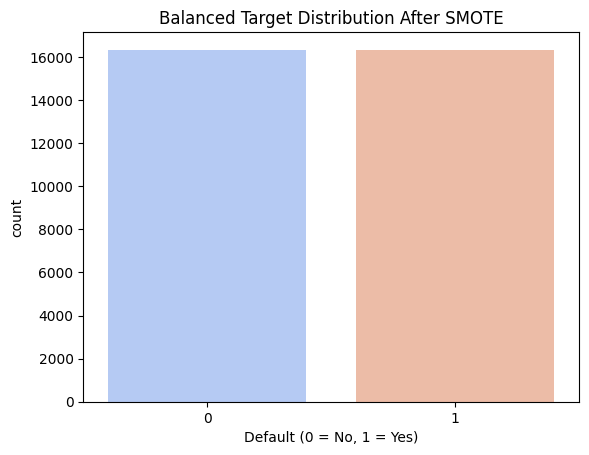

In [ ]:
# ==========================================
# 📦 INSTALL REQUIRED LIBRARIES
# ==========================================
!pip install imbalanced-learn --quiet
!pip install seaborn --quiet
!pip install matplotlib --quiet
!pip install scikit-learn --quiet

# ==========================================
# 📚 IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# ==========================================
# 📂 UPLOAD DATA FILE MANUALLY
# ==========================================
from google.colab import files
print("📁 Please upload your UCI_Credit_Card.csv file:")
uploaded = files.upload()

# ==========================================
# 🧹 LOAD AND CLEAN DATA
# ==========================================
df = pd.read_csv("UCI_Credit_Card.csv")

if "default.payment.next.month" in df.columns:
    df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
if "ID" in df.columns:
    df.drop(columns="ID", inplace=True)

# Show class distribution before cleaning
print("\nClass distribution before cleaning:\n", df["default"].value_counts())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Remove outliers — careful to retain class balance
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# If cleaning removes all defaults, revert to original data
if df_cleaned["default"].nunique() < 2:
    print("\n⚠️ Outlier removal dropped minority class — reverting to unfiltered dataset.")
    df = df.copy()
else:
    df = df_cleaned

print(f"\n✅ Cleaning complete. Shape: {df.shape}")
print("Class balance after cleaning:\n", df["default"].value_counts())

# ==========================================
# ✂️ TRAIN-TEST SPLIT (Stratified)
# ==========================================
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nBefore Resampling:\n", y_train.value_counts())

# ==========================================
# ⚖️ BALANCE DATA USING SMOTE
# ==========================================
if len(y_train.unique()) == 2:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("\nAfter SMOTE:\n", y_train_res.value_counts())
else:
    print("\n⚠️ Only one class in training data — cannot apply SMOTE.")
    X_train_res, y_train_res = X_train, y_train


# ==========================================
# 🧠 FEATURE SELECTION (Filter + Wrapper)
# ==========================================
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression

# Filter Method (ANOVA F-test)
filter_sel = SelectKBest(score_func=f_classif, k=min(15, X_train_res.shape[1]-1))
X_train_filter = filter_sel.fit_transform(X_train_res, y_train_res)
X_test_filter = filter_sel.transform(X_test)
selected_filter = X_train.columns[filter_sel.get_support()]

# Wrapper (RFE) with more iterations for convergence
estimator = LogisticRegression(max_iter=2000)  # ✅ increased from 1000 to 2000
rfe = RFE(estimator, n_features_to_select=min(10, X_train_filter.shape[1]))
rfe.fit(X_train_filter, y_train_res)
selected_wrapper = selected_filter[rfe.support_]

print("\n✅ Selected Features (RFE):", list(selected_wrapper))


# ==========================================
# 🔄 NORMALIZE NUMERICAL FEATURES
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res[selected_wrapper])
X_test_scaled = scaler.transform(X_test[selected_wrapper])

print("\n✅ Final Preprocessed Data Shapes:",
      "\nX_train:", X_train_scaled.shape,
      "\nX_test:", X_test_scaled.shape)

# ==========================================
# 📊 VISUALIZE CLASS BALANCE
# ==========================================
sns.countplot(x=y_train_res, palette="coolwarm")
plt.title("Balanced Target Distribution After SMOTE")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.show()


✅ Decision Tree Classifier Results:
Accuracy: 81.46 %

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      7001
           1       0.64      0.37      0.47      1989

    accuracy                           0.81      8990
   macro avg       0.74      0.66      0.68      8990
weighted avg       0.80      0.81      0.80      8990



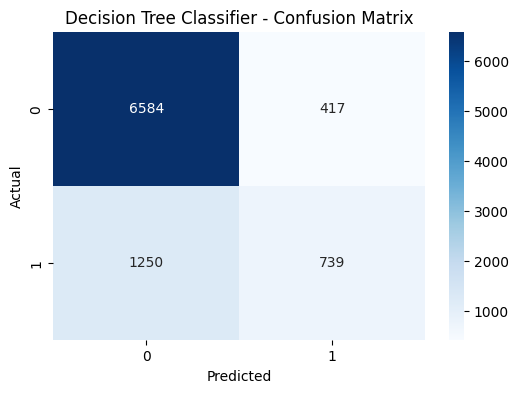

In [ ]:
# ==========================================
# Decision Tree Classifier (DTC)
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train model
dtc = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    random_state=42
)
dtc.fit(X_train, y_train)

# Predictions
y_pred_dtc = dtc.predict(X_test)

# Evaluation
print("✅ Decision Tree Classifier Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dtc) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dtc))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_dtc)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Classifier - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

/tmp/ipython-input-740276295.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df_dtc, palette='Blues_d')


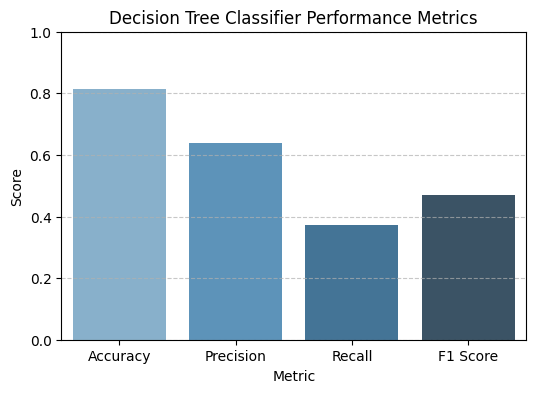

In [ ]:
# ==========================================
# 📊 Decision Tree Performance Metrics Visualization
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute performance metrics
metrics_dtc = {
    'Accuracy': accuracy_score(y_test, y_pred_dtc),
    'Precision': precision_score(y_test, y_pred_dtc),
    'Recall': recall_score(y_test, y_pred_dtc),
    'F1 Score': f1_score(y_test, y_pred_dtc)
}

# Convert to DataFrame for plotting
metrics_df_dtc = pd.DataFrame(list(metrics_dtc.items()), columns=['Metric', 'Score'])

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x='Metric', y='Score', data=metrics_df_dtc, palette='Blues_d')
plt.title('Decision Tree Classifier Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

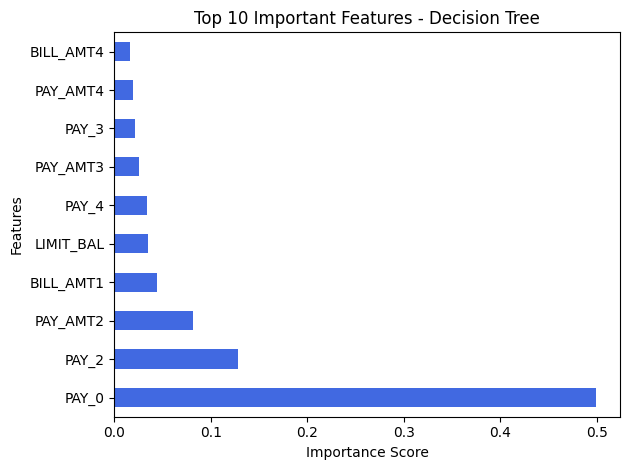

In [ ]:
# Feature Importance Visualization (fixed)
feature_importance = pd.Series(dtc.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).plot(kind='barh', color='royalblue')

plt.title('Top 10 Important Features - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()



In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# 🔍 Grid Search Optimization - Decision Tree
# ==========================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dtc = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

print("🚀 Running Grid Search for Decision Tree...")
grid_dtc.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid_dtc.best_params_)
print("✅ Best Cross-Validation Accuracy:", round(grid_dtc.best_score_ * 100, 2), "%")

# Evaluate best model on test set
best_dtc = grid_dtc.best_estimator_
y_pred_gs_dtc = best_dtc.predict(X_test)
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_gs_dtc) * 100, 2), "%")


🚀 Running Grid Search for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
✅ Best Cross-Validation Accuracy: 81.81 %

Test Accuracy: 81.9 %


In [ ]:
# ==========================================
# 📊 Classification Report for Best DTC Model
# ==========================================
from sklearn.metrics import classification_report

print("📄 Classification Report for Best Decision Tree Model:\n")
print(classification_report(y_test, y_pred_gs_dtc))

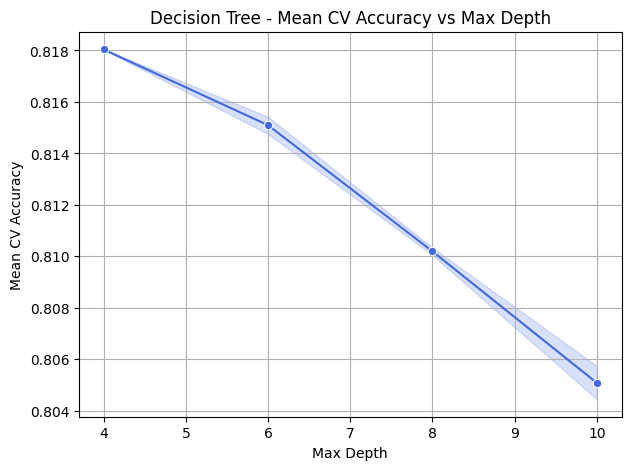

In [ ]:
# ==========================================
# 📊 Visualization — Mean Test Accuracy vs Max Depth
# ==========================================
results = pd.DataFrame(grid_dtc.cv_results_)
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=results,
    x='param_max_depth',
    y='mean_test_score',
    marker='o',
    color='royalblue'
)
plt.title("Decision Tree - Mean CV Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)
plt.show()